In this notebook, we will make a multi-panel plot of the spectra !

In [87]:
import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import matplotlib.ticker as mticker
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18
import glob
from matplotlib.lines import Line2D

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code/nebular_stuff'))

sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code/stacking_analysis'))


from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs, process_img
from desi_lowz_funcs import calc_normalized_dist, sdss_rgb, get_scrollable_pdfs
from desi_lowz_funcs import find_objects_nearby, print_radecs
# from construct_dwarf_galaxy_catalogs import process_sga_matches

import warnings
from astropy.wcs import FITSFixedWarning

from desi_lowz_funcs import plot_2d_dist, make_subplots

# Suppress just FITSFixedWarning
warnings.filterwarnings('ignore', category=FITSFixedWarning)

from sfr_and_metallicity import compute_o32, compute_r32
from sfr_and_metallicity import line_snr_mask
from catalog_paper_plots import make_cmap
from catalog_paper_plots import make_cmap
import cmasher as cmr
from scipy.stats import gaussian_kde

from pn_functions import compute_direct_metallicities

%load_ext autoreload
%autoreload 2


    



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [88]:

import matplotlib as mpl

mpl.rcParams.update({
    # --- Fonts (your existing sizes + cmr10 serif from new style) ---
    'font.family':                 'serif',
    'font.serif':                  'cmr10',
    'font.size':                   11,
    'mathtext.fontset':            'cm',
    'axes.unicode_minus':          False,
    'axes.formatter.use_mathtext': True,
    'axes.labelsize':              12,
    'axes.titlesize':              12,
    'xtick.labelsize':             10,
    'ytick.labelsize':             10,
    'legend.fontsize':             11,

    # --- Axes ---
    'axes.linewidth':              1.0,
    'axes.xmargin':                0.05,

    # --- X ticks: in, all sides, minor ticks on ---
    'xtick.direction':             'in',
    'xtick.top':                   True,
    'xtick.minor.visible':         True,
    'xtick.major.top':             True,
    'xtick.minor.top':             True,
    'xtick.major.size':            3.5,
    'xtick.minor.size':            2.0,
    'xtick.major.width':           1.0,
    'xtick.minor.width':           0.8,
    'xtick.major.pad':             4,
    'xtick.minor.pad':             4,

    # --- Y ticks: in, all sides, minor ticks on ---
    'ytick.direction':             'in',
    'ytick.right':                 True,
    'ytick.minor.visible':         True,
    'ytick.major.right':           True,
    'ytick.minor.right':           True,
    'ytick.major.size':            3.5,
    'ytick.minor.size':            2.0,
    'ytick.major.width':           1.0,
    'ytick.minor.width':           0.8,
    'ytick.major.pad':             4,
    'ytick.minor.pad':             4,

    # --- Legend ---
    'legend.frameon':              False,
    'legend.edgecolor':            'k',
    'legend.framealpha':           0,

    # --- Figure / savefig / misc ---
    'figure.facecolor':            'w',
    'image.aspect':                'auto',
    'image.cmap':                  'magma',
    'savefig.format':              'pdf',
    'savefig.bbox':                'standard',
    'savefig.dpi':                 300,
    'savefig.transparent':         False,
    'errorbar.capsize':            0,
    'lines.markersize':            5,
    'hist.bins':                   'auto',
})


MARGIN_LABEL  = 0.9   # edge with axis label + tick labels
MARGIN_TICKS  = 0.45  # edge with only tick labels (no axis label)
MARGIN_PAD    = 0.2   # edge with nothing
MARGIN_SHARED = 0.1   # gap between panels sharing an axis
MARGIN_SPLIT  = 0.7   # gap between panels with independent axes
MARGIN_CBAR   = 1.1   # edge with a colorbar



In [145]:
def air_to_vac(wave_air):
    """Air -> vacuum wavelength conversion (Morton 2000), valid for lambda > 2000 A."""
    wave_air = np.asarray(wave_air, dtype=float)
    s = 1e4 / wave_air
    n = (1 + 0.00008336624212083
         + 0.02408926869968 / (130.1065924522 - s**2)
         + 0.0001599740894897 / (38.92568793293 - s**2))
    return wave_air * n


In [89]:
STACK_PATH = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar_haew_5pct/"


In [135]:
label = "mstar_8.00_8.50_ew_p80_100"   # pick a bin
fits_file = f"{STACK_PATH}stack_ALL_{label}.fits"

with fits.open(fits_file) as hdul:
  wave = hdul["WAVE"].data          # rest-frame vacuum Angstroms, 1D
  flux = hdul["FLUX"].data          # (n_rows, n_wave); row 0 = mean stack
  ivar = hdul["IVAR"].data
  info = hdul["STACKINFO"].data     # NOBJ, MSTAR_MIN/MAX, EW_MIN/MAX, ...

flux_mean = flux[0]
err_mean = 1.0 / np.sqrt(ivar[0])     # ivar -> 1-sigma uncertainty
err_mean[~np.isfinite(err_mean)] = np.nan


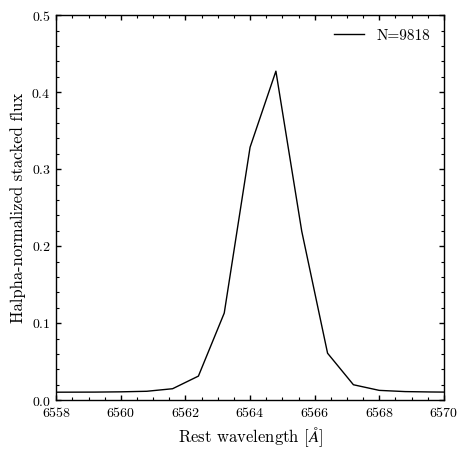

In [136]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(wave, flux_mean, color="k", lw=1,
      label=f"N={info['NOBJ'][0]}")
ax.set_xlim(wave.min(), wave.max())
ax.set_xlabel(r"Rest wavelength [$\AA$]")
ax.set_ylabel("Halpha-normalized stacked flux")
ax.legend(frameon=False)
ax.set_xlim([6555+3,6570])
ax.set_ylim([0,0.5])
plt.show()

In [137]:
halpha_mask = (wave > 6555+3) & (wave < 6570)
wave_int = wave[halpha_mask]
flux_int = flux_mean[halpha_mask]

print( np.sum( np.diff(wave_int)[0] * flux_int ) )

1.0348846884899103


In [138]:
wave.min(),  wave.max()

(np.float64(3600.0), np.float64(6799.2001953125))

In [139]:
wave_edges = np.arange(3600, 6800,533)

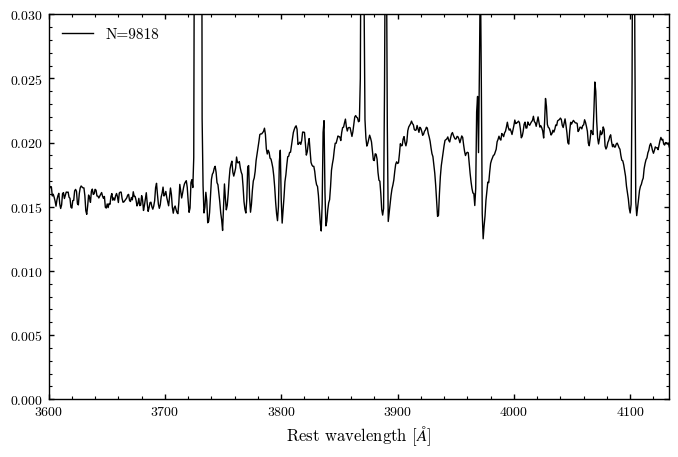

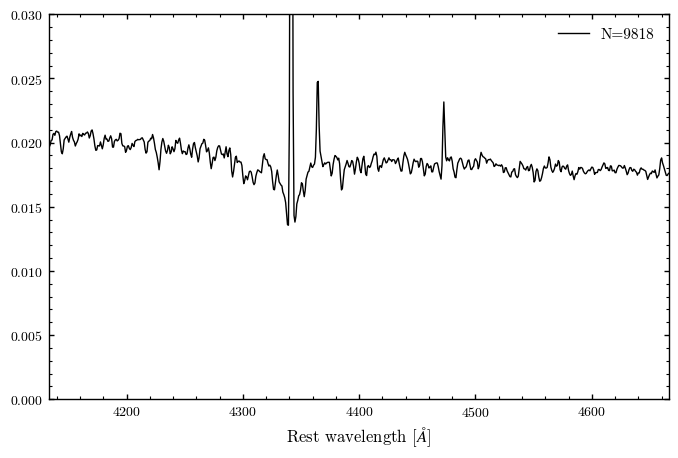

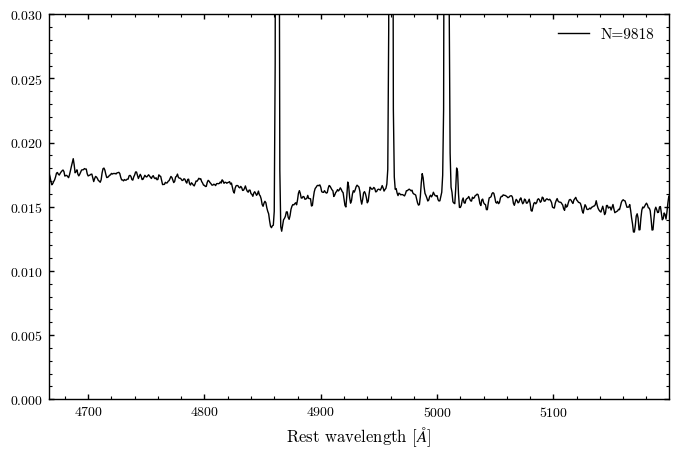

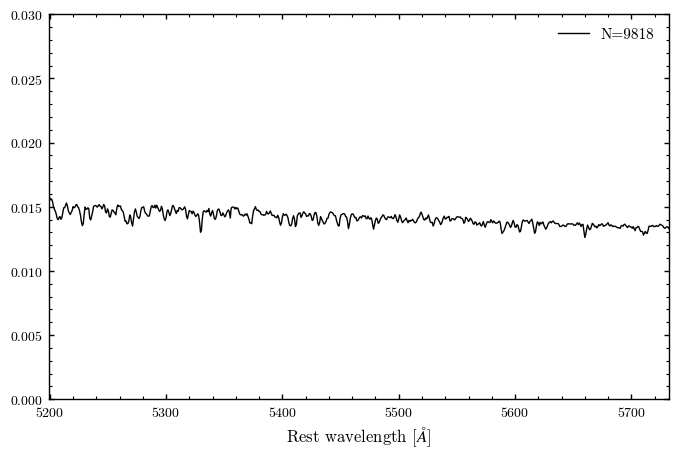

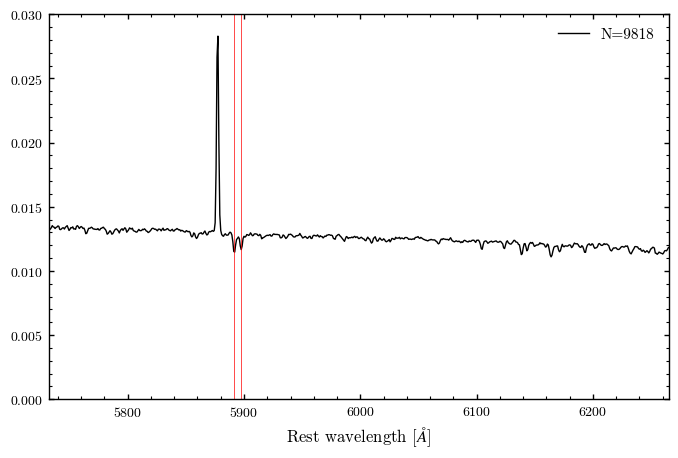

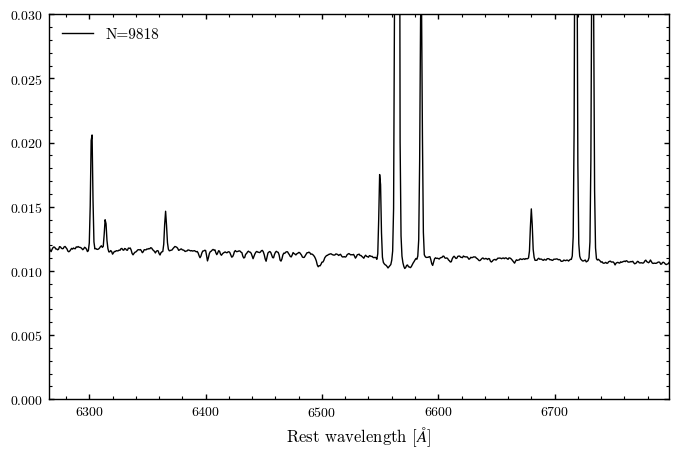

In [146]:

for i in range(len(wave_edges)-1):
    fig, ax = plt.subplots(figsize=(8,5))
    ax.plot(wave, flux_mean, color="k", lw=1,
          label=f"N={info['NOBJ'][0]}")
    ax.set_xlim(wave_edges[i], wave_edges[i+1] )
    ax.set_xlabel(r"Rest wavelength [$\AA$]")

    

    ax.axvline(x=air_to_vac(5890), lw = 0.5, color = "r")
    ax.axvline(x=air_to_vac(5896), lw = 0.5, color = "r")
    
    ax.legend(frameon=False)
    ax.set_ylim([0,0.03])
    plt.show()

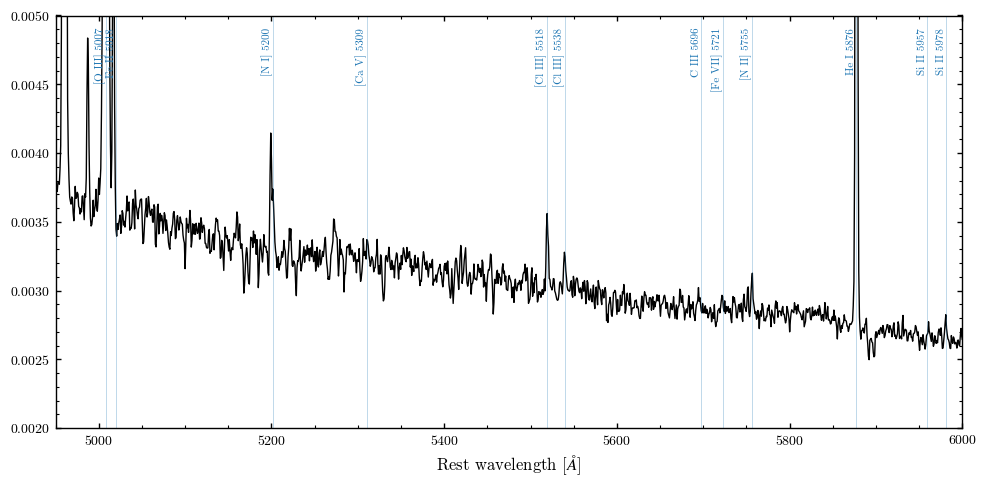

In [63]:
import numpy as np
from matplotlib.transforms import blended_transform_factory


# Air wavelengths [Angstrom]. Comment out any key you don't want to plot.
lines = {
    "[O III] 5007":  5006.843,
    "Fe II 5018":    5018.440,
    "[N I] 5200":    5200.257,
    "[Ca V] 5309":   5309.110,
    "[Cl III] 5518": 5517.709,
    "[Cl III] 5538": 5537.873,
    "C III 5696":    5695.920,
    "[Fe VII] 5721":    5721.1,
    "[N II] 5755":   5754.590,
    "He I 5876":     5875.624,
    "Si II 5957":     5957.61,
    "Si II 5978":     5978.97,
    
}

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(wave, flux_mean, color="k", lw=1)
# ax.fill_between(wave, flux_mean - err_mean, flux_mean + err_mean,
#               color="k", alpha=0.2, lw=0)
ax.set_xlabel(r"Rest wavelength [$\AA$]")
ax.set_ylim([0.002, 0.005])
# ax.set_ylim([0.003, 0.007])
ax.set_xlim([4950, 6000])


# Blended transform: x in data coords, y in axes-fraction (0-1).
trans = blended_transform_factory(ax.transData, ax.transAxes)
xlo, xhi = ax.get_xlim()

for label, wl_air in lines.items():
    wl_vac = float(air_to_vac(wl_air))    
    if not (xlo <= wl_vac <= xhi):
        continue
    # full-height guide line, faint and thin so it doesn't dominate
    ax.axvline(wl_vac, color="C0", lw=0.5, alpha=0.4)
    # label written inside the plot, running up along the line
    ax.text(wl_vac, 0.97, label, rotation=90, ha="right", va="top",
            fontsize=8, color="C0", transform=trans,
            alpha=1)

fig.tight_layout()
plt.show()

In [57]:
## ok so I want to do some stacked spectra plot!!